**Table of contents**<a id='toc0_'></a>    
- [Antibunching monitored with FCS](#toc1_)    
  - [Different fluorophore count](#toc1_1_)    
  - [S-S-annihilation](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Antibunching monitored with FCS](#toc0_)

In [ ]:
import numpy as np

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.simulation as si
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

fluopy.fcs version: 0.1.0
fluopy.figure version: 0.1.0
fluopy.emissions version: 0.1.0
fluopy.simulation version: 0.1.0
fluopy.transitions version: 0.1.0
fluopy.fluorophores version: 0.1.0


## <a id='toc1_1_'></a>[Different fluorophore count](#toc0_)

WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.70e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04. 
WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 8.50e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04. 
WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 5.67e-13.
 This was estimated using the highest possible rate

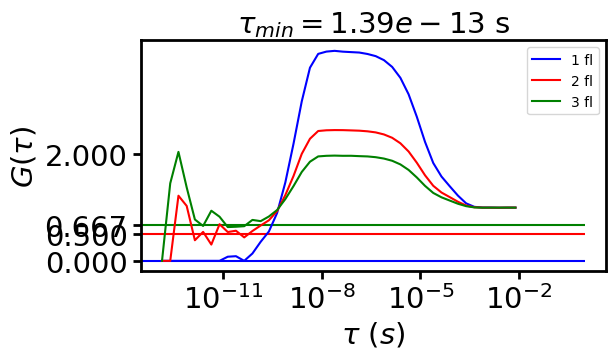

In [ ]:
rng = np.random.default_rng(3)
ax = fi.universal_figure(yticks=[0, 0.5, 2 / 3, 2])
colors = ["blue", "red", "green"]
ax[0, 0].hlines(y=[0, 0.5, 2 / 3], xmin=0, xmax=1, colors=colors)
for i in range(3):
    number_fluorophores = i + 1
    fluorophores = fl.construct_fluorophores(
        name="cy5_dna", distance=10, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = fluorophore_system.load_transitions(
        irradiance=2.5,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(start_at=None, size=5e7, end_time=None, seed=rng, use_memmap=None)
    emissions = em.Emissions(frame_time="1s", seed=rng, bandpass=[200, 800])
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions)
    fcs.autocorrelate_time_points(exp_min=-13, exp_max=-2)
    fcs.plot(axes=ax, color=colors[i], label=f"{number_fluorophores} fl", legend=True)

## <a id='toc1_2_'></a>[S-S-annihilation](#toc0_)

WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 5.67e-13.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04. 
WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 3.15e-14.
 This was estimated using the highest possible rate which occurs for example in state combination [1, 1, 1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+02 - 1.00e+03. 
WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.62e-14.
 This was estimated using the highest poss

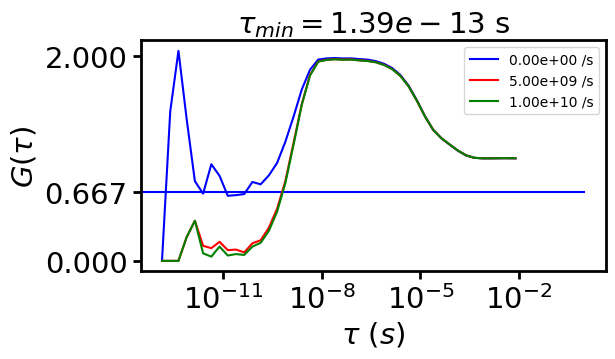

In [ ]:
rng = np.random.default_rng(4)
ax = fi.universal_figure(yticks=[0, 2 / 3, 2])
ax[0, 0].hlines(y=2 / 3, xmin=0, xmax=1, colors="blue")
for i in range(3):
    fluorophores = fl.construct_fluorophores(
        name="cy5_dna", distance=10, count=3, shape="triangle"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)
    transitions = fluorophore_system.load_transitions(
        irradiance=2.5,
        wavelength=640,
        bleaching=False,
        energy_transfer=False,
        dstorm=False,
    )
    s_s_annihilation = tr.Transition(
        tr.TransitionType.S_S_ANNIHILATION,
        rate=i * 5e9,
        fluorophore_ids=[(0, 1), (1, 0), (0, 2), (2, 0), (1, 2), (2, 1)],
    )
    transitions["D: cy5_dna, A: cy5_dna, dist: 10.0"] = [s_s_annihilation]
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()
    simulation = si.Simulation(transition_set)
    simulation.run(start_at=None, size=5e7, end_time=None, seed=rng, use_memmap=None)
    emissions = em.Emissions(frame_time="1s", seed=rng, bandpass=[200, 800])
    emissions.extract(simulation)
    fcs = fcs_p.FCS(emissions)
    fcs.autocorrelate_time_points(exp_min=-13, exp_max=-2)
    fcs.plot(axes=ax, color=colors[i], label=f"{i * 5e9:.2e} /s", legend=True)